In [1]:
from numpy import pi
import pint
from simulation import SimulationConfig, OpticalForceCalculator, DipoleCalculator, SweepRunner
from comsol_data import parse_file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
ureg = pint.UnitRegistry()

/home/uspensky/PyProjects/Mie_SPP_Force/.venv/lib/python3.12/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [7]:
wavelen = 640
rad = 30
pmaterial = "Si"

baseConfig = SimulationConfig(
    wl=wavelen * ureg.nanometer,
    R=rad * ureg.nanometer,
    dist=1 * ureg.nanometer,
    angle=np.deg2rad(0),
    psi=pi/2,
    chi=pi/4,
    substrate='Air',
    particle=pmaterial,
    amplitude=0.1444,
    show_warnings=False,
    initial_field_type='custom',
    z_beam= 1E-12 * ureg.nanometer,
    w0=450*ureg.nanometer,
    xp=0*ureg.nanometer
)

Custom field parameters set: w0=450 nanometer, z_beam=1e-12 nanometer


## По x

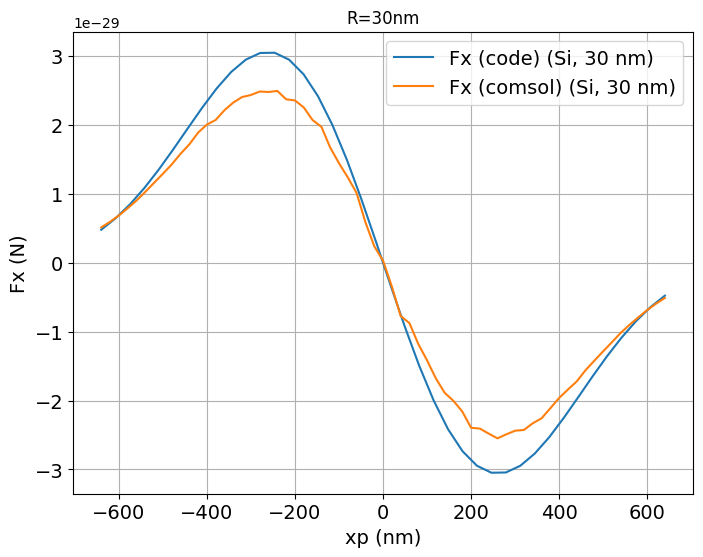

In [13]:
output_filename = "force_computation_results/" + pmaterial +"_Fx_" + str(rad) + "nm.csv"
if os.path.exists(output_filename):
    pass
else:
    xmesh = np.linspace(-wavelen, wavelen, 40) * ureg.nanometer
    data_code, _, _ = SweepRunner(baseConfig, 'xp', xmesh, compute_force=True, compute_dipoles=False, compute_diagram=False).run()

    with open(output_filename, 'w') as file:
        file.write('xp (m),Fx (N)\n')
        for j in range(len(xmesh)):
            file.write(str(xmesh[j].magnitude))
            file.write(',')
            file.write(str(data_code.Fx[j].magnitude))
            file.write('\n')

data_code_x = pd.read_csv(output_filename)
data_comsol_x = parse_file("/home/uspensky/ComsolData/wl640nm_x_Si_r10-90nm_nosubs.csv")
i = rad // 10 - 1

plt.figure(figsize=(8, 6))
plt.plot(data_code_x["xp (m)"], data_code_x["Fx (N)"], label=f'Fx (code) (Si, {rad} nm)')
plt.plot(1E9*data_comsol_x[i]["xp (m)"], data_comsol_x[i]["Fx (N)"], label=f"Fx (comsol) (Si, {round(data_comsol_x[i]["% r (m)"].iloc[0]*1E9)} nm)")
plt.xlabel("xp (nm)", fontsize=14)
plt.ylabel("Fx (N)", fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14, loc='upper right')
plt.title(f'R={rad}nm')
plt.grid()

## По z

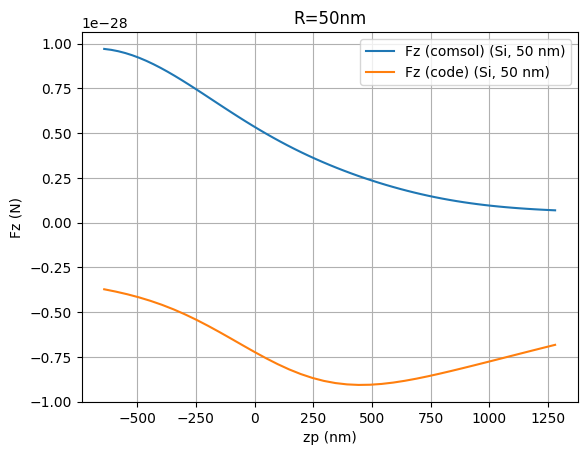

In [ ]:
output_filename = "force_computation_results/" + pmaterial + "_Fz_"+str(rad)+"nm.csv"
if os.path.exists(output_filename):
    pass
else:
    fmesh = np.linspace(-2*wavelen, wavelen, 40) * ureg.nanometer
    data_code, _, _ = SweepRunner(baseConfig, 'z_beam', fmesh, compute_force=True, compute_dipoles=False, compute_diagram=False).run()

    with open(output_filename, 'w') as file:
        file.write('f (m),Fz (N)\n')
        for j in range(len(fmesh)):
            file.write(str(fmesh[j].magnitude))
            file.write(',')
            file.write(str(data_code.Fz[j].magnitude))
            file.write('\n')

data_code_z = pd.read_csv(output_filename)
data_comsol_z = parse_file("/home/uspensky/ComsolData/wl640nm_z_Si_r10-90nm_nosubs.csv")
i = rad // 10 - 1

plt.plot(-1E9*data_comsol_z[i]["f (m)"], data_comsol_z[i]["Fz (N)"], label=f"Fz (comsol) (Si, {round(data_comsol_z[i]["% r (m)"].iloc[0]*1E9)} nm)")
plt.plot(-data_code_z['f (m)'], data_code_z['Fz (N)'], label=f'Fz (code) (Si, {rad} nm)')

plt.xlabel("zp (nm)")
plt.ylabel("Fz (N)")

plt.legend()
plt.title(f'R={rad}nm')
plt.grid()